### MNIST contains:

60,000 training images
10,000 testing images

Each image is 28 x 28 pixels


### Why to Use ReLu?
1. Fast
2. Reduces vanishing gradients
3. Most common activation function

c:\Users\AMD\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8657 - loss: 0.4659 - val_accuracy: 0.9550 - val_loss: 0.1458
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9666 - loss: 0.1063 - val_accuracy: 0.9607 - val_loss: 0.1345
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9763 - loss: 0.0771 - val_accuracy: 0.9712 - val_loss: 0.0940
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9839 - loss: 0.0523 - val_accuracy: 0.9729 - val_loss: 0.0945
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9865 - loss: 0.0423 - val_accuracy: 0.9733 - val_loss: 0.0949
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9704 - loss: 0.0931

Test Accuracy: 0.9748
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


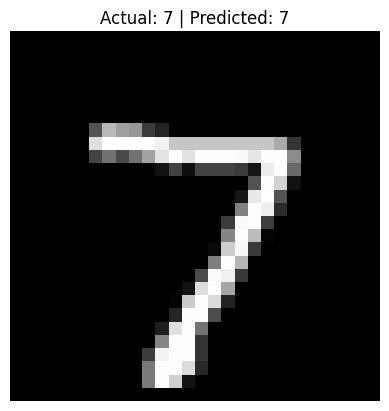

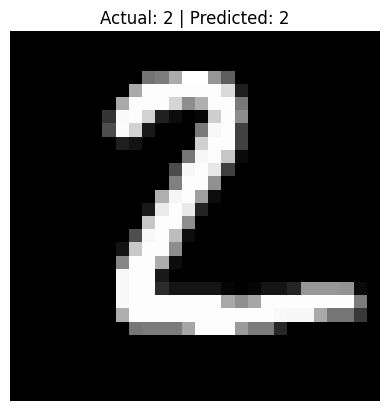

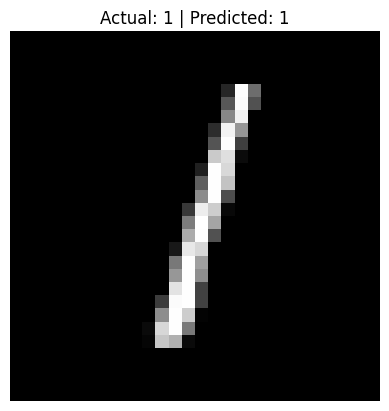

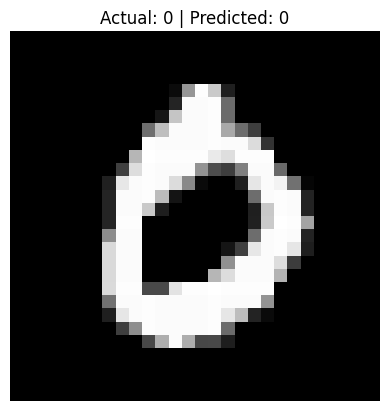

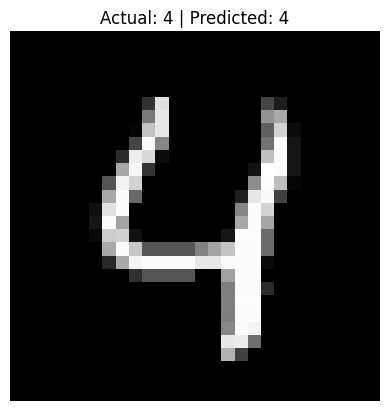

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
import matplotlib.pyplot as plt
import numpy as np


(X_train, Y_train), (X_test, Y_test) = tf.keras.datasets.mnist.load_data()

# Normalizing the data (values will now range from 0 to 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(), # converts 28 x 28 into 784
    # So basically [[1,2], [3,4]] becomes [1,2,3,4]. Since MLP cannot directly process images, 1D vectors are required.
    Dense(128, activation='relu'),
    Dense(64, activation='relu'), #The network learns more abstract patterns due to compression from 128 to 64 neurons
    Dense(10, activation='softmax') # Softmax produces probabilities. 
    # Whichever class has the highest probability will be returned as the final class.
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() #Shows Layer names, Output shapes, Number of parameters

history = model.fit(
    X_train,
    Y_train,
    epochs=5,
    batch_size=32,#Understanding mini-batch gradient descent here
    validation_split=0.2 # 20% of the data is used for validation
)

test_loss, test_accuracy = model.evaluate(X_test, Y_test) # Model is tested on unseen images

print(f"\nTest Accuracy: {test_accuracy:.4f}")

predictions = model.predict(X_test[:5]) # Predicts first 5 test images.
# (5,10) will be the output shape because 5 images and 10 probabilities each.

for i in range(5):
    predicted_label = np.argmax(predictions[i]) # We get the predicted class with the highest probability

    plt.imshow(X_test[i], cmap='gray') # Shows the handwritten digit.
    plt.title(
        f"Actual: {Y_test[i]} | Predicted: {predicted_label}" # Compares actual class and predicted class
    )
    plt.axis('off')
    plt.show()